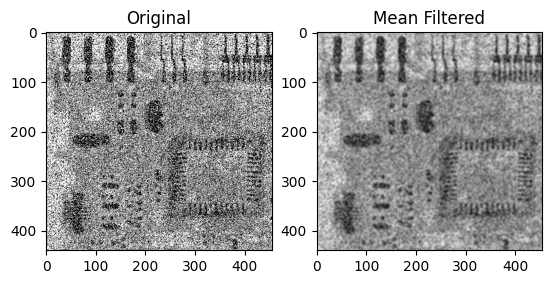

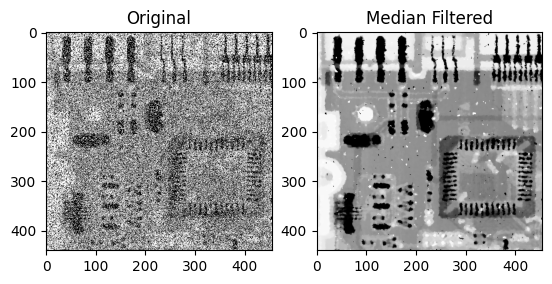

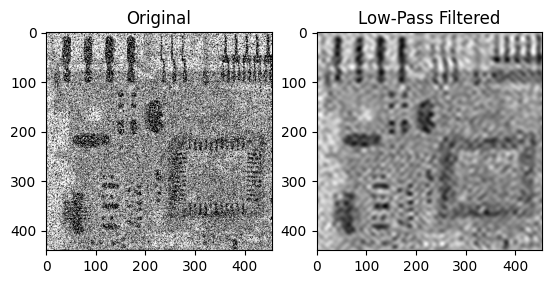

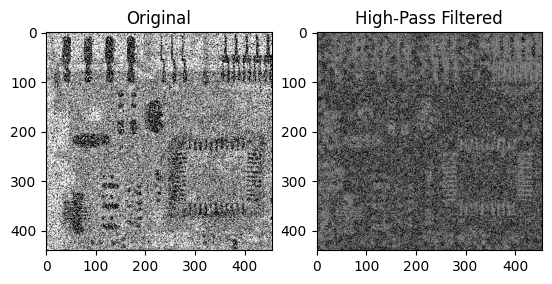

In [4]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
# Carregar a imagem 
image = cv2.imread('imagens/salt_noise.png', 0) 
# Aplicar o filtro de média 
mean_filtered = cv2.blur(image, (5, 5)) 
# Mostrar a imagem original e a filtrada 
plt.subplot(1, 2, 1), 
plt.imshow(image, cmap='gray'),
plt.title('Original') 
plt.subplot(1, 2, 2),
plt.imshow(mean_filtered, cmap='gray'), 
plt.title('Mean Filtered') 
plt.show()
# b. Filtro de Mediana (Median Filter) O filtro de mediana é eficaz na remoção de ruído sal e pimenta, substituindo cada pixel pelo valor mediano dos pixels em sua vizinhança.
# # Aplicar o filtro de mediana 
median_filtered = cv2.medianBlur(image, 5) 
# Mostrar a imagem original e a filtrada 
plt.subplot(1, 2, 1), 
plt.imshow(image, cmap='gray'), 
plt.title('Original') 
plt.subplot(1, 2, 2), 
plt.imshow(median_filtered, cmap='gray'), 
plt.title('Median Filtered') 
plt.show()
# 2. Filtros no Domínio da Frequência Os filtros no domínio da frequência operam sobre a transformada de Fourier da imagem. Eles são úteis para remover ruídos de alta ou baixa frequência. 
# a. Filtro Passa-Baixa (Low-Pass Filter) Um filtro passa-baixa permite a passagem de frequências baixas e atenua as frequências altas, suavizando a imagem.
# Transformada de Fourier 
dft = cv2.dft(np.float32(image), 
flags=cv2.DFT_COMPLEX_OUTPUT) 
dft_shift = np.fft.fftshift(dft) 
# Criar um filtro passa-baixa 
rows, cols = image.shape 
crow, ccol = rows // 2 , cols // 2 
mask = np.zeros((rows, cols, 2), np.uint8) 
mask[crow-30:crow+30, ccol-30:ccol+30] = 1 
# Aplicar o filtro 
fshift = dft_shift * mask 
f_ishift = np.fft.ifftshift(fshift) 
img_back = cv2.idft(f_ishift) 
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1]) 
# Mostrar a imagem original e a filtrada 
plt.subplot(1, 2, 1), 
plt.imshow(image, cmap='gray'), 
plt.title('Original') 
plt.subplot(1, 2, 2), 
plt.imshow(img_back, cmap='gray'), 
plt.title('Low-Pass Filtered') 
plt.show() 
# b. Filtro Passa-Alta (High-Pass Filter) Um filtro passa-alta permite a passagem de frequências altas e atenua as frequências baixas, destacando os detalhes e bordas da imagem. 
# Criar um filtro passa-alta 
mask = np.ones((rows, cols, 2), np.uint8) 
mask[crow-30:crow+30, ccol-30:ccol+30] = 0 
# Aplicar o filtro 
fshift = dft_shift * mask 
f_ishift = np.fft.ifftshift(fshift) 
img_back = cv2.idft(f_ishift) 
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1]) 
# Mostrar a imagem original e a filtrada 
plt.subplot(1, 2, 1), 
plt.imshow(image, cmap='gray'), 
plt.title('Original') 
plt.subplot(1, 2, 2), 
plt.imshow(img_back, cmap='gray'), 
plt.title('High-Pass Filtered') 
plt.show() 